# 1. Importación de librerías, carga de los archivos y preparación de los datos:

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [2]:
df = pd.read_csv("/datasets/games.csv")

In [3]:
print("Las primeras 10 filas")
print(df.head(10))
print("="*50)
print("="*50)
print("\nResumen del DataFrame")
print(df.info())
print("="*50)
print("="*50)
print("\nEstadísticas del DataFrame")
print(df.describe())

Las primeras 10 filas
                        Name Platform  Year_of_Release         Genre  \
0                 Wii Sports      Wii           2006.0        Sports   
1          Super Mario Bros.      NES           1985.0      Platform   
2             Mario Kart Wii      Wii           2008.0        Racing   
3          Wii Sports Resort      Wii           2009.0        Sports   
4   Pokemon Red/Pokemon Blue       GB           1996.0  Role-Playing   
5                     Tetris       GB           1989.0        Puzzle   
6      New Super Mario Bros.       DS           2006.0      Platform   
7                   Wii Play      Wii           2006.0          Misc   
8  New Super Mario Bros. Wii      Wii           2009.0      Platform   
9                  Duck Hunt      NES           1984.0       Shooter   

   NA_sales  EU_sales  JP_sales  Other_sales  Critic_Score User_Score Rating  
0     41.36     28.96      3.77         8.45          76.0          8      E  
1     29.08      3.58      

### Trabajando los nombres de las columnas

In [4]:
df.columns = df.columns.str.lower()
print("Nombres de columnas actualizados:")
print(df.columns)

Nombres de columnas actualizados:
Index(['name', 'platform', 'year_of_release', 'genre', 'na_sales', 'eu_sales',
       'jp_sales', 'other_sales', 'critic_score', 'user_score', 'rating'],
      dtype='object')


### Eliminando valores nulos de ["name"] y ["genre"]

In [5]:
df.dropna(subset=["name", "genre"], inplace=True)
print(f"Filas después de eliminar NaN en 'name' y 'genre': {len(df)}")

Filas después de eliminar NaN en 'name' y 'genre': 16713


### Tratamiento de ["year_of_release"]

In [6]:

df.dropna(subset=['year_of_release'], inplace=True)
print(f"Filas después de eliminar NaN en 'year_of_release': {len(df)}")
print("="*50)


df["year_of_release"] = df["year_of_release"].astype(int)
print("Tipo de dato de 'year_of_release' actualizado:", df["year_of_release"].dtype)
print("="*50)

Filas después de eliminar NaN en 'year_of_release': 16444
Tipo de dato de 'year_of_release' actualizado: int64


### Tratamiento de ["user_score"]

In [7]:
df["user_score"] = df["user_score"].replace("tbd", np.nan)

df["user_score"] = pd.to_numeric(df["user_score"], errors="coerce")
print("Tipo de dato de 'user_score' actualizado:", df["user_score"].dtype)
print("="*50)

Tipo de dato de 'user_score' actualizado: float64


In [8]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
Int64Index: 16444 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             16444 non-null  object 
 1   platform         16444 non-null  object 
 2   year_of_release  16444 non-null  int64  
 3   genre            16444 non-null  object 
 4   na_sales         16444 non-null  float64
 5   eu_sales         16444 non-null  float64
 6   jp_sales         16444 non-null  float64
 7   other_sales      16444 non-null  float64
 8   critic_score     7983 non-null   float64
 9   user_score       7463 non-null   float64
 10  rating           9768 non-null   object 
dtypes: float64(6), int64(1), object(4)
memory usage: 1.5+ MB
None


### Ventas totales por región:

In [9]:
print("Ventas totales por región (suma de todos los juegos):")
print(f"Ventas en Norteamérica (NA): {df['na_sales'].sum():.2f} millones")
print(f"Ventas en Europa (EU): {df['eu_sales'].sum():.2f} millones")
print(f"Ventas en Japón (JP): {df['jp_sales'].sum():.2f} millones")
print(f"Ventas en Otras regiones: {df['other_sales'].sum():.2f} millones")
print("="*50)

df["total_sales"] = df["na_sales"] + df["eu_sales"] + df["jp_sales"] + df["other_sales"]
print("Primeras 10 filas con la nueva columna 'total_sales':")
print(df.head(10))
print("="*50)

Ventas totales por región (suma de todos los juegos):
Ventas en Norteamérica (NA): 4341.42 millones
Ventas en Europa (EU): 2399.68 millones
Ventas en Japón (JP): 1290.64 millones
Ventas en Otras regiones: 782.63 millones
Primeras 10 filas con la nueva columna 'total_sales':
                        name platform  year_of_release         genre  \
0                 Wii Sports      Wii             2006        Sports   
1          Super Mario Bros.      NES             1985      Platform   
2             Mario Kart Wii      Wii             2008        Racing   
3          Wii Sports Resort      Wii             2009        Sports   
4   Pokemon Red/Pokemon Blue       GB             1996  Role-Playing   
5                     Tetris       GB             1989        Puzzle   
6      New Super Mario Bros.       DS             2006      Platform   
7                   Wii Play      Wii             2006          Misc   
8  New Super Mario Bros. Wii      Wii             2009      Platform   
9    

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 16444 entries, 0 to 16714
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             16444 non-null  object 
 1   platform         16444 non-null  object 
 2   year_of_release  16444 non-null  int64  
 3   genre            16444 non-null  object 
 4   na_sales         16444 non-null  float64
 5   eu_sales         16444 non-null  float64
 6   jp_sales         16444 non-null  float64
 7   other_sales      16444 non-null  float64
 8   critic_score     7983 non-null   float64
 9   user_score       7463 non-null   float64
 10  rating           9768 non-null   object 
 11  total_sales      16444 non-null  float64
dtypes: float64(7), int64(1), object(4)
memory usage: 1.6+ MB


# 2. Analysis de datos:

### Analysis de juegos lanzados por año:

In [11]:
plt.style.use("ggplot") # Estilo extraído de python-charts.com

games_per_year = df["year_of_release"].value_counts().sort_index()

print("Número de juegos lanzados por año:")
print(games_per_year)
print("="*50)

Número de juegos lanzados por año:
1980       9
1981      46
1982      36
1983      17
1984      14
1985      14
1986      21
1987      16
1988      15
1989      17
1990      16
1991      41
1992      43
1993      60
1994     121
1995     219
1996     263
1997     289
1998     379
1999     338
2000     350
2001     482
2002     829
2003     775
2004     762
2005     939
2006    1006
2007    1197
2008    1427
2009    1426
2010    1255
2011    1136
2012     653
2013     544
2014     581
2015     606
2016     502
Name: year_of_release, dtype: int64


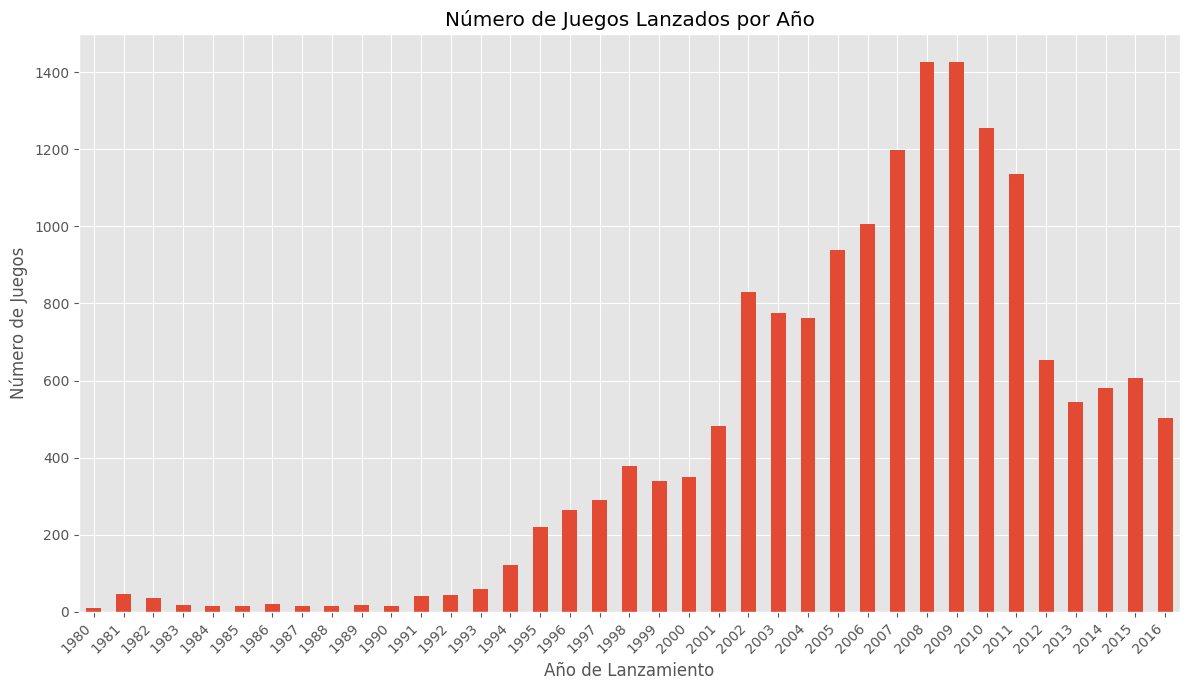


Últimos 10 años en detalle:
2007    1197
2008    1427
2009    1426
2010    1255
2011    1136
2012     653
2013     544
2014     581
2015     606
2016     502
Name: year_of_release, dtype: int64


In [12]:
plt.figure(figsize=(12, 7)) # 12x7 va a ser el tamaño estándar que utilizaré de ahora en adelante para todos los gráficos.
games_per_year.plot(kind="bar") 
plt.title("Número de Juegos Lanzados por Año")
plt.xlabel("Año de Lanzamiento")
plt.ylabel("Número de Juegos")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

print("\nÚltimos 10 años en detalle:")
print(games_per_year.tail(10))
print("="*50) # Para que no se confunda con el texto de abajo.

### Analysis de la variación de ventas por plataforma

In [13]:
platform_sales = df.groupby("platform")["total_sales"].sum().sort_values(ascending=False)

print("Ventas totales por plataforma (en millones USD):")
print(platform_sales)

Ventas totales por plataforma (en millones USD):
platform
PS2     1233.56
X360     961.24
PS3      931.34
Wii      891.18
DS       802.78
PS       727.58
PS4      314.14
GBA      312.88
PSP      289.53
3DS      257.81
PC       255.76
GB       254.43
XB       251.57
NES      251.05
N64      218.01
SNES     200.04
GC       196.73
XOne     159.32
2600      86.48
WiiU      82.19
PSV       53.81
SAT       33.59
GEN       28.35
DC        15.95
SCD        1.86
NG         1.44
WS         1.42
TG16       0.16
3DO        0.10
GG         0.04
PCFX       0.03
Name: total_sales, dtype: float64


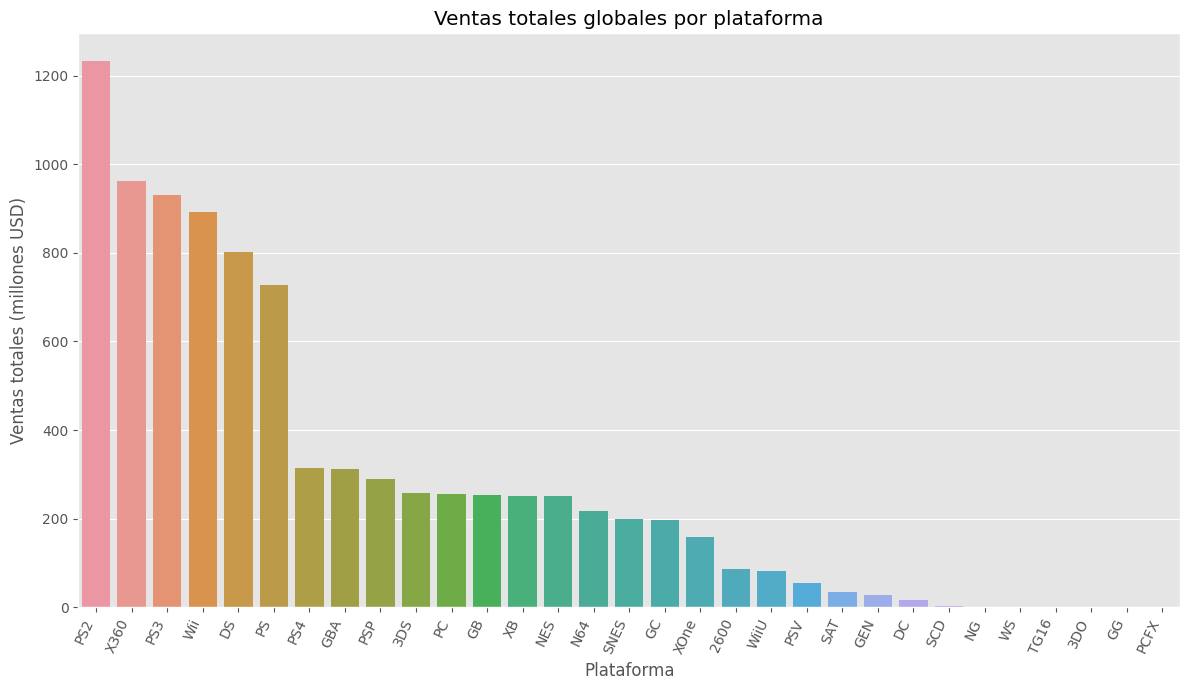

In [14]:
plt.figure(figsize=(12, 7))
sns.barplot(x=platform_sales.index, y=platform_sales.values)
plt.title("Ventas totales globales por plataforma")
plt.xlabel("Plataforma")
plt.ylabel("Ventas totales (millones USD)")
plt.xticks(rotation=65, ha="right")
plt.tight_layout()
plt.show()

Analizando las ventas anuales de las 10 plataformas principales: ['PS2', 'X360', 'PS3', 'Wii', 'DS', 'PS', 'PS4', 'GBA', 'PSP', '3DS']


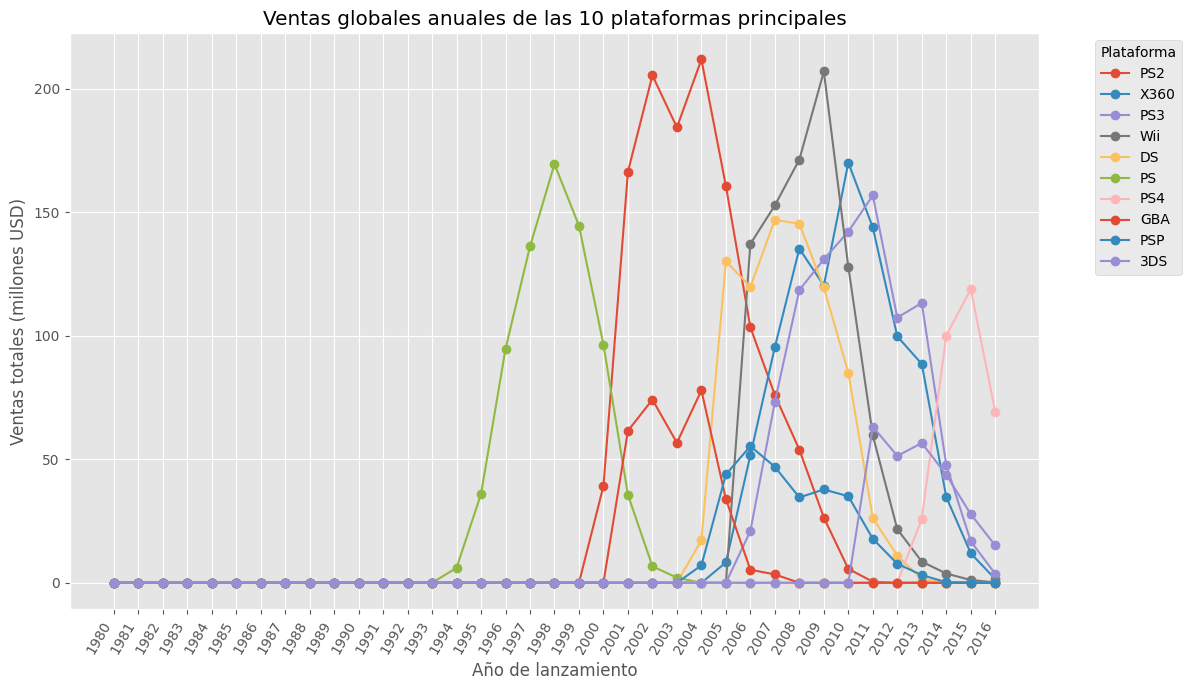

In [15]:
top_platforms = platform_sales.head(10).index.tolist()

print(f"Analizando las ventas anuales de las 10 plataformas principales: {top_platforms}")
print("="*50)

platform_annual_sales = df.pivot_table(index="year_of_release",
                                       columns="platform",
                                       values="total_sales",
                                       aggfunc="sum")

platform_annual_sales_top = platform_annual_sales[top_platforms].fillna(0) # Relleno con 0 para marcar los años en los que la plataforma no había salido.

platform_annual_sales_top.plot(kind="line", figsize=(12, 7), marker="o", lw=1.5)
plt.title("Ventas globales anuales de las 10 plataformas principales")
plt.xlabel("Año de lanzamiento")
plt.ylabel("Ventas totales (millones USD)")
plt.xticks(platform_annual_sales_top.index, rotation=60, ha="right") # Emparejamiento de ["year_of_release"] con cada tick del gráfico
plt.legend(title="Plataforma", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()
print("="*50)

In [16]:
print("Análisis de la vida útil de las plataformas (sólo años con ventas):")
platform_lifespan = {}
for platform in df["platform"].unique():
    years_with_sales = df[df["platform"] == platform]["year_of_release"].unique()
    if len(years_with_sales) > 0:
        min_year = years_with_sales.min()
        max_year = years_with_sales.max()
        lifespan = max_year - min_year + 1
        platform_lifespan[platform] = {"first_year": min_year,
                                       "last_year": max_year,
                                       "lifespan_years": lifespan}
    else:
        platform_lifespan[platform] = {"first_year": None,
                                       "last_year": None,
                                       "lifespan_years": 0}

lifespan_df = pd.DataFrame.from_dict(platform_lifespan, orient="index")
lifespan_df.index.name = "Platform"
lifespan_df.sort_values(by="lifespan_years", ascending=False, inplace=True)

print(lifespan_df) # Plataformas ordenadas según su vida útil
print("\nNota: Una 'vida útil' de 1 año indica que solo se registró un año de ventas.")
print("="*50)

Análisis de la vida útil de las plataformas (sólo años con ventas):
          first_year  last_year  lifespan_years
Platform                                       
PC              1985       2016              32
DS              1985       2013              29
GB              1988       2001              14
X360            2005       2016              12
PS2             2000       2011              12
PSP             2004       2015              12
NES             1983       1994              12
Wii             2006       2016              11
PS3             2006       2016              11
DC              1998       2008              11
PS              1994       2003              10
2600            1980       1989              10
SNES            1990       1999              10
XB              2000       2008               9
GBA             2000       2007               8
GC              2001       2007               7
N64             1996       2002               7
3DS             2011

In [17]:
current_max_year = df["year_of_release"].max()
print(f"El año más reciente en el dataset es: {current_max_year}")
print("\nPlataformas populares (Top 10 en ventas) con ventas terminadas antes de 2015:")
for platform in top_platforms:
    if platform in lifespan_df.index:
        if lifespan_df.loc[platform]["last_year"] < 2015: 
            print(f"-> {platform} - Último año con ventas = {lifespan_df.loc[platform]['last_year']}")

El año más reciente en el dataset es: 2016

Plataformas populares (Top 10 en ventas) con ventas terminadas antes de 2015:
-> PS2 - Último año con ventas = 2011
-> DS - Último año con ventas = 2013
-> PS - Último año con ventas = 2003
-> GBA - Último año con ventas = 2007


In [18]:
relevant_years = df["year_of_release"].between(2014, 2016) # Encontré el método between para seleccionar rangos de datos
df_current = df[relevant_years].copy()

print(f"DataFrame filtrado para los años 2014-2016. Número de entradas: {len(df_current)}")
print("\nDistribución de juegos en el período actual:")
print(df_current["year_of_release"].value_counts().sort_index())
print("="*50)

DataFrame filtrado para los años 2014-2016. Número de entradas: 1689

Distribución de juegos en el período actual:
2014    581
2015    606
2016    502
Name: year_of_release, dtype: int64


Ventas totales por plataforma en 2014-2016 (millones USD):
platform
PS4     288.15
XOne    140.36
3DS      86.68
PS3      68.18
X360     48.22
WiiU     42.98
PC       27.05
PSV      22.40
Wii       5.07
PSP       0.36
Name: total_sales, dtype: float64


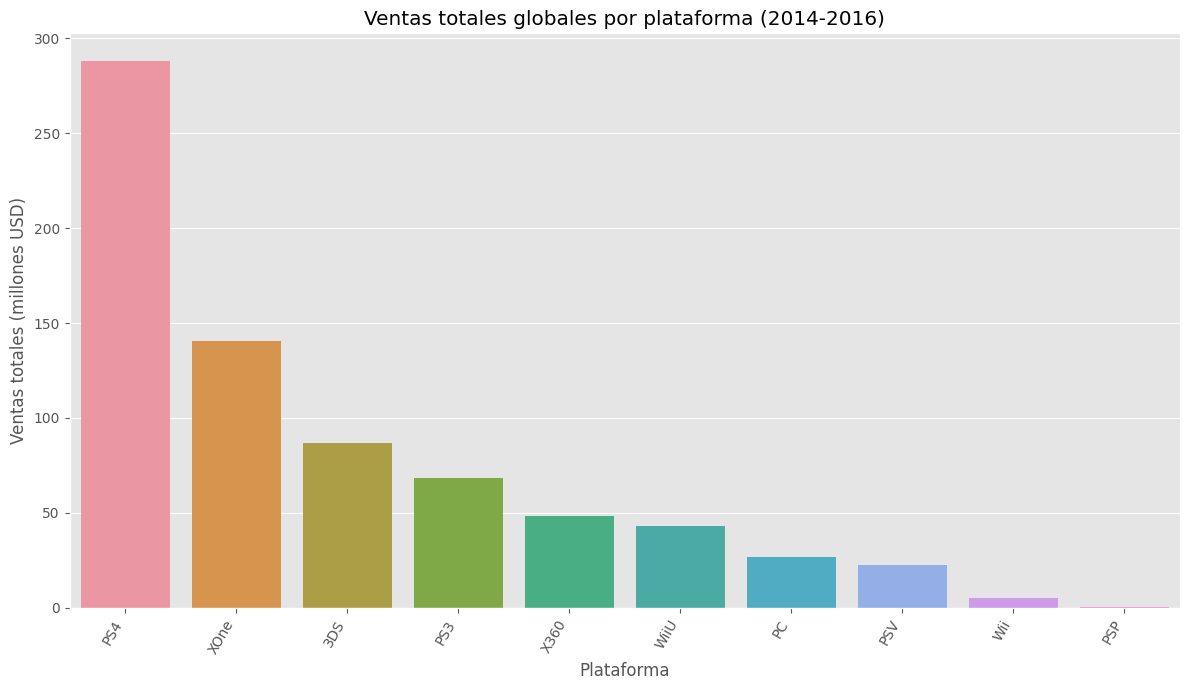

In [19]:
platform_sales_current = df_current.groupby("platform")["total_sales"].sum().sort_values(ascending=False)

print("Ventas totales por plataforma en 2014-2016 (millones USD):")
print(platform_sales_current)
print("="*50)

plt.figure(figsize=(12, 7))
sns.barplot(x=platform_sales_current.index, y=platform_sales_current.values)
plt.title("Ventas totales globales por plataforma (2014-2016)")
plt.xlabel("Plataforma")
plt.ylabel("Ventas totales (millones USD)")
plt.xticks(rotation=60, ha="right")
plt.tight_layout()
plt.show()

Analizando ventas anuales de las top 10 plataformas en 2014-2016: ['PS4', 'XOne', '3DS', 'PS3', 'X360', 'WiiU', 'PC', 'PSV', 'Wii', 'PSP']


<Figure size 1000x600 with 0 Axes>

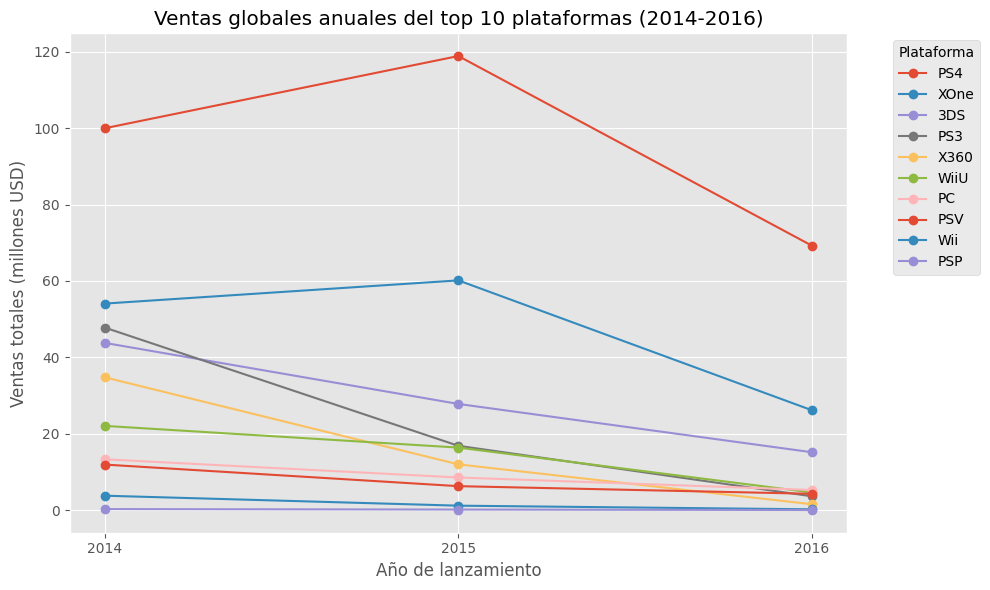

In [20]:
top_platforms_current = platform_sales_current.head(10).index.tolist()

print(f"Analizando ventas anuales de las top 10 plataformas en 2014-2016: {top_platforms_current}")
platform_annual_sales_current = df_current.pivot_table(index="year_of_release",
                                                       columns="platform",
                                                       values="total_sales",
                                                       aggfunc="sum")
platform_annual_sales_current = platform_annual_sales_current[top_platforms_current].fillna(0)

plt.figure(figsize=(10, 6))
platform_annual_sales_current.plot(kind="line", figsize=(10, 6), marker="o", lw=1.5)
plt.title("Ventas globales anuales del top 10 plataformas (2014-2016)")
plt.xlabel("Año de lanzamiento")
plt.ylabel("Ventas totales (millones USD)")
plt.xticks(platform_annual_sales_current.index, rotation=0)
plt.legend(title="Plataforma", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()
print("="*50)

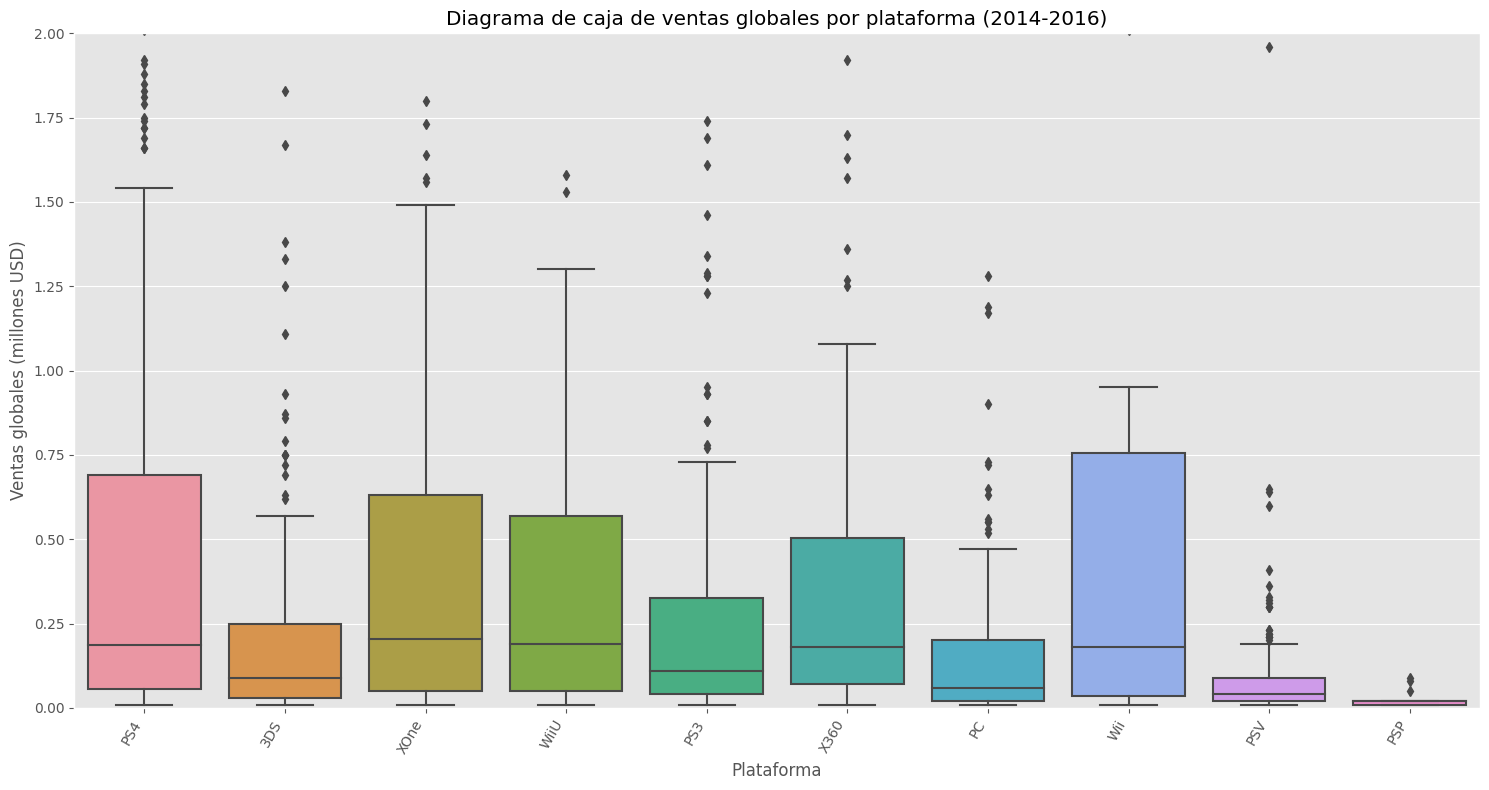

In [21]:
plt.figure(figsize=(15, 8))
sns.boxplot(x="platform", y="total_sales", data=df_current)
plt.title("Diagrama de caja de ventas globales por plataforma (2014-2016)")
plt.xlabel("Plataforma")
plt.ylabel("Ventas globales (millones USD)")
plt.ylim(0, 2) # Tuve que limitar el eje Y para abarcar la mayor cantidad de datos en una buena visualización, ya que hay valores atípicos muy altos
plt.xticks(rotation=60, ha="right")
plt.tight_layout()
plt.show()


Análisis de Reseñas y Ventas para la plataforma: PS4
Número de juegos con reseñas y ventas disponibles en PS4: 234


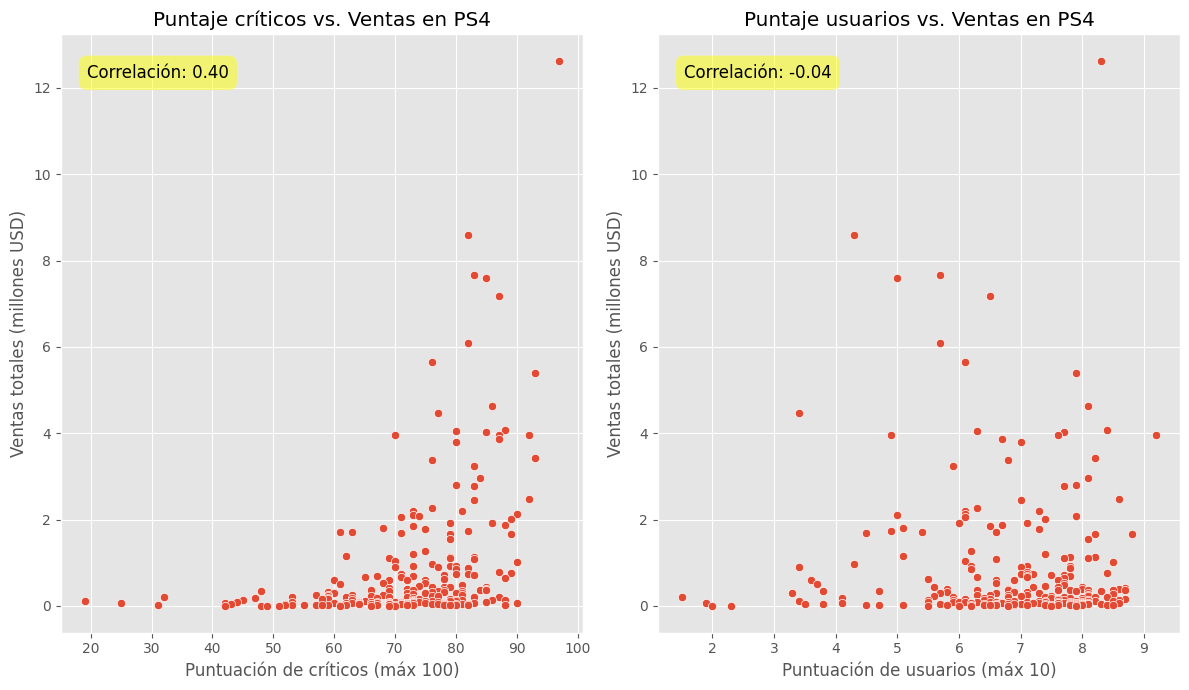

Correlación entre 'critic_score' y 'total_sales' en PS4: 0.40
Correlación entre 'user_score' y 'total_sales' en PS4: -0.04


In [22]:
platform_choice = "PS4"
df_ps4 = df_current[df_current["platform"] == platform_choice].copy() # Una copia para no alterar el df original

df_ps4_clean = df_ps4.dropna(subset=["critic_score", "user_score", "total_sales"])

print(f"\nAnálisis de Reseñas y Ventas para la plataforma: {platform_choice}")
print(f"Número de juegos con reseñas y ventas disponibles en {platform_choice}: {len(df_ps4_clean)}")
print("="*50)

if len(df_ps4_clean) > 0:
    plt.figure(figsize=(12, 7))
    plt.subplot(1, 2, 1) 
    sns.scatterplot(x="critic_score", y="total_sales", data=df_ps4_clean)
    plt.title(f"Puntaje críticos vs. Ventas en {platform_choice}")
    plt.xlabel("Puntuación de críticos (máx 100)")
    plt.ylabel("Ventas totales (millones USD)")

    critic_corr = df_ps4_clean["critic_score"].corr(df_ps4_clean["total_sales"])
    plt.text(0.05, 0.95, f"Correlación: {critic_corr:.2f}", transform=plt.gca().transAxes,
             fontsize=12, verticalalignment="top", bbox=dict(boxstyle="round,pad=0.5", fc="yellow", alpha=0.5))


    plt.subplot(1, 2, 2)
    sns.scatterplot(x="user_score", y="total_sales", data=df_ps4_clean)
    plt.title(f"Puntaje usuarios vs. Ventas en {platform_choice}")
    plt.xlabel("Puntuación de usuarios (máx 10)")
    plt.ylabel("Ventas totales (millones USD)")

    user_corr = df_ps4_clean["user_score"].corr(df_ps4_clean["total_sales"])
    plt.text(0.05, 0.95, f"Correlación: {user_corr:.2f}", transform=plt.gca().transAxes,
             fontsize=12, verticalalignment="top", bbox=dict(boxstyle="round,pad=0.5", fc="yellow", alpha=0.5))

    plt.tight_layout()
    plt.show()

    print(f"Correlación entre 'critic_score' y 'total_sales' en {platform_choice}: {critic_corr:.2f}")
    print(f"Correlación entre 'user_score' y 'total_sales' en {platform_choice}: {user_corr:.2f}")

else:
    print(f"No hay suficientes datos con puntuaciones y ventas para {platform_choice} en el período 2014-2016 para realizar este análisis.")

print("="*50)

Ventas totales por género en 2014-2016 (millones USD):
genre
Action          199.36
Shooter         170.94
Sports          109.48
Role-Playing    101.44
Misc             37.55
Fighting         28.22
Racing           27.52
Platform         18.09
Adventure        17.55
Simulation       13.13
Strategy          3.96
Puzzle            2.21
Name: total_sales, dtype: float64
Número de juegos por género en 2014-2016:
Action          619
Role-Playing    221
Adventure       185
Sports          161
Shooter         128
Misc            113
Racing           69
Fighting         60
Simulation       44
Platform         38
Strategy         37
Puzzle           14
Name: genre, dtype: int64


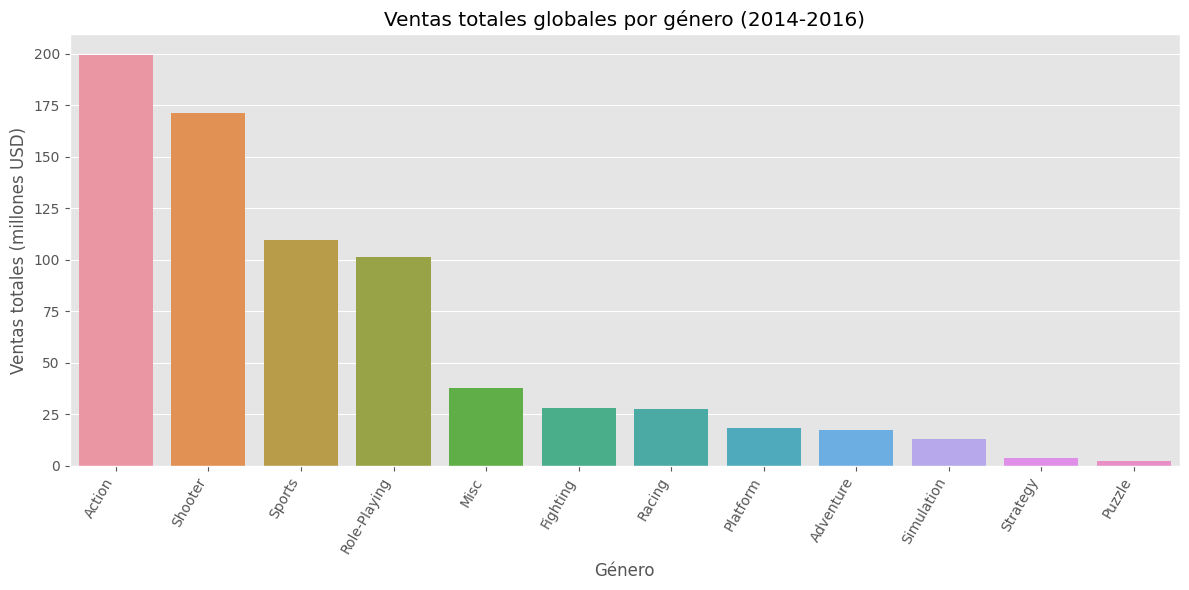

In [23]:
genre_sales_current = df_current.groupby("genre")["total_sales"].sum().sort_values(ascending=False)

print("Ventas totales por género en 2014-2016 (millones USD):")
print(genre_sales_current)
print("="*50)

genre_counts_current = df_current["genre"].value_counts().sort_values(ascending=False)
print("Número de juegos por género en 2014-2016:")
print(genre_counts_current)
print("="*50)

plt.figure(figsize=(12, 6))
sns.barplot(x=genre_sales_current.index, y=genre_sales_current.values)
plt.title("Ventas totales globales por género (2014-2016)")
plt.xlabel("Género")
plt.ylabel("Ventas totales (millones USD)")
plt.xticks(rotation=60, ha="right")
plt.tight_layout()
plt.show()


============ Top 5 plataformas por región ============

Top 5 Plataformas en Norteamérica (2014-2016):
platform
PS4     98.61
XOne    81.27
X360    28.30
3DS     22.64
PS3     22.05
Name: na_sales, dtype: float64


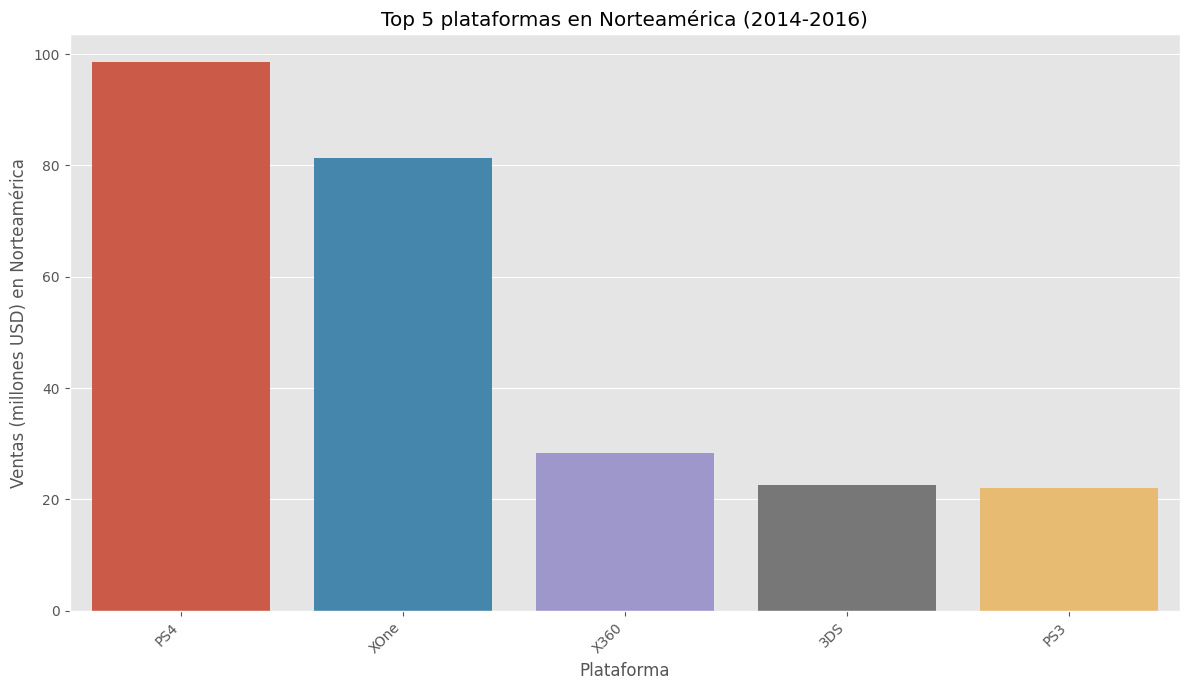


Top 5 Plataformas en Europa (2014-2016):
platform
PS4     130.04
XOne     46.25
PS3      25.54
PC       17.97
3DS      16.12
Name: eu_sales, dtype: float64


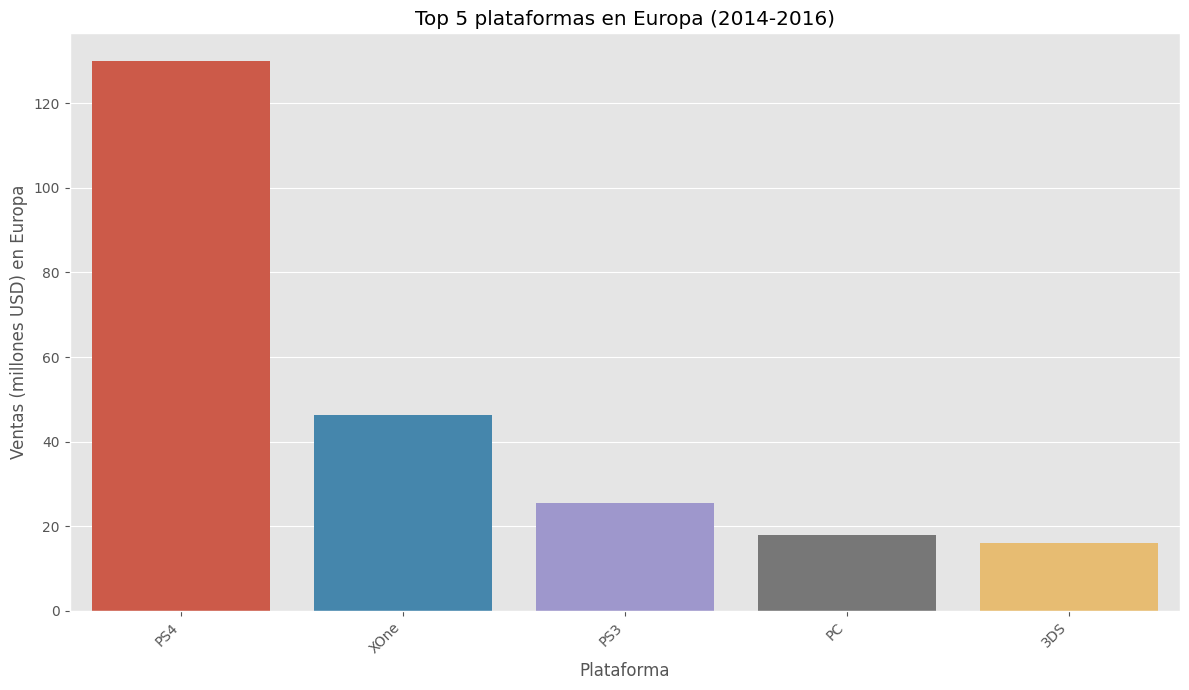


Top 5 Plataformas en Japón (2014-2016):
platform
3DS     44.24
PS4     15.02
PSV     14.54
PS3     11.22
WiiU     7.31
Name: jp_sales, dtype: float64


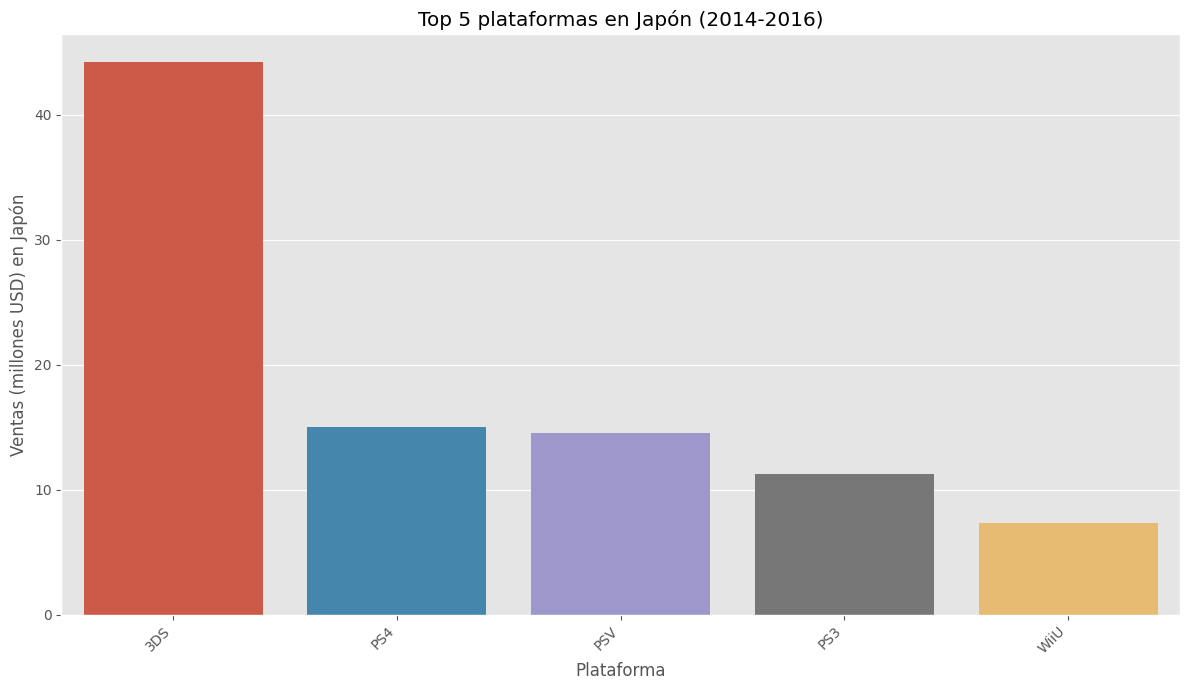

In [24]:
regions = ["na_sales", "eu_sales", "jp_sales"]
region_names = {"na_sales": "Norteamérica", "eu_sales": "Europa", "jp_sales": "Japón"}

print("============ Top 5 plataformas por región ============")
for region_col in regions:
    top_platforms_region = df_current.groupby("platform")[region_col].sum().sort_values(ascending=False).head(5)

    print(f"\nTop 5 Plataformas en {region_names[region_col]} (2014-2016):")
    print(top_platforms_region)

    plt.figure(figsize=(12, 7))
    sns.barplot(x=top_platforms_region.index, y=top_platforms_region.values)
    plt.title(f"Top 5 plataformas en {region_names[region_col]} (2014-2016)")
    plt.xlabel("Plataforma")
    plt.ylabel(f"Ventas (millones USD) en {region_names[region_col]}")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

============ Top 5 géneros por región ============

Top 5 géneros en Norteamérica (2014-2016):
genre
Shooter         79.02
Action          72.53
Sports          46.13
Role-Playing    33.47
Misc            15.05
Name: na_sales, dtype: float64


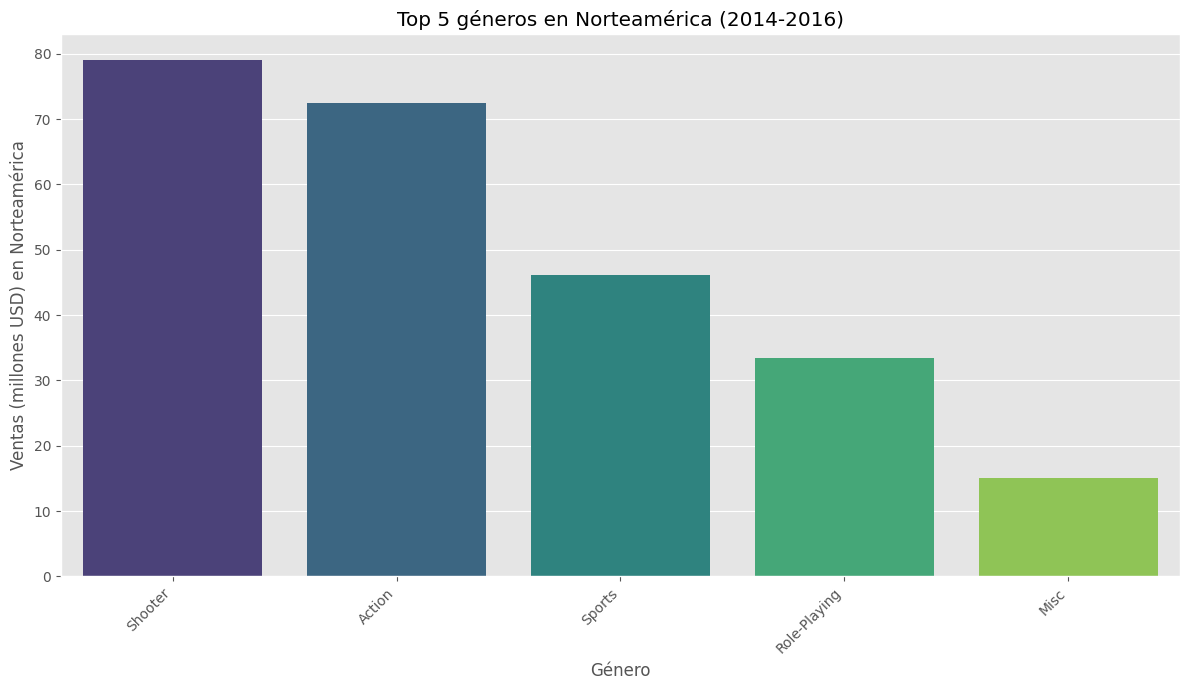


Top 5 géneros en Europa (2014-2016):
genre
Action          74.68
Shooter         65.52
Sports          45.73
Role-Playing    28.17
Racing          14.13
Name: eu_sales, dtype: float64


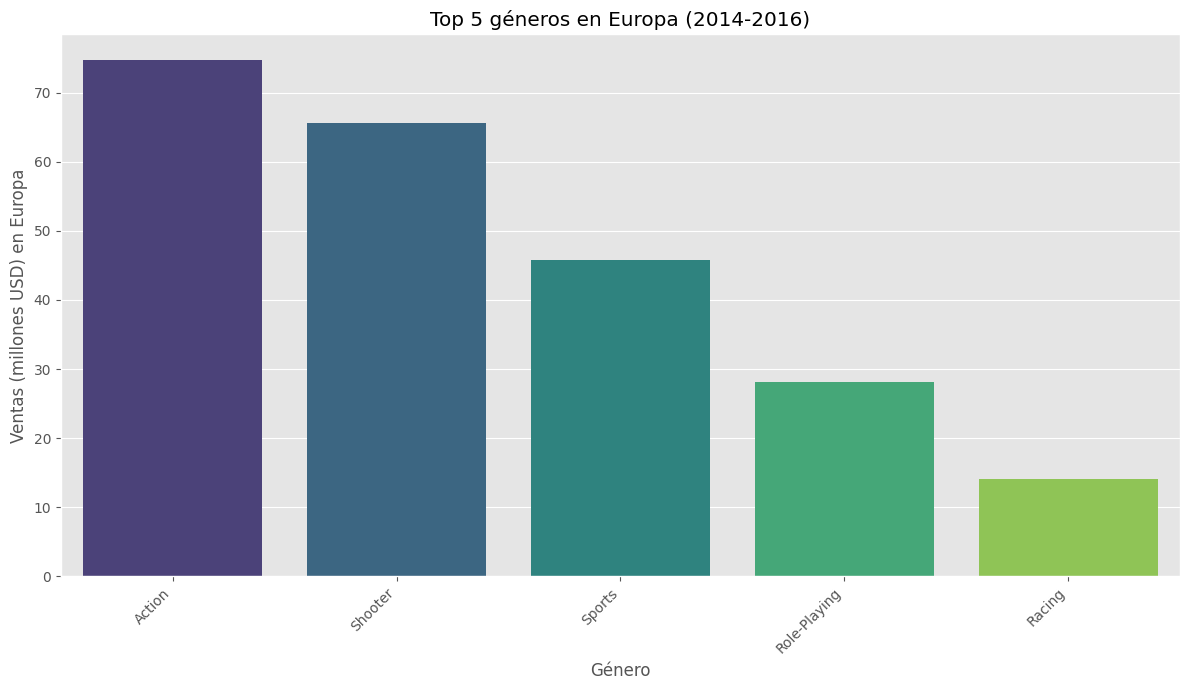


Top 5 géneros en Japón (2014-2016):
genre
Role-Playing    31.16
Action          29.58
Fighting         6.37
Misc             5.61
Shooter          4.87
Name: jp_sales, dtype: float64


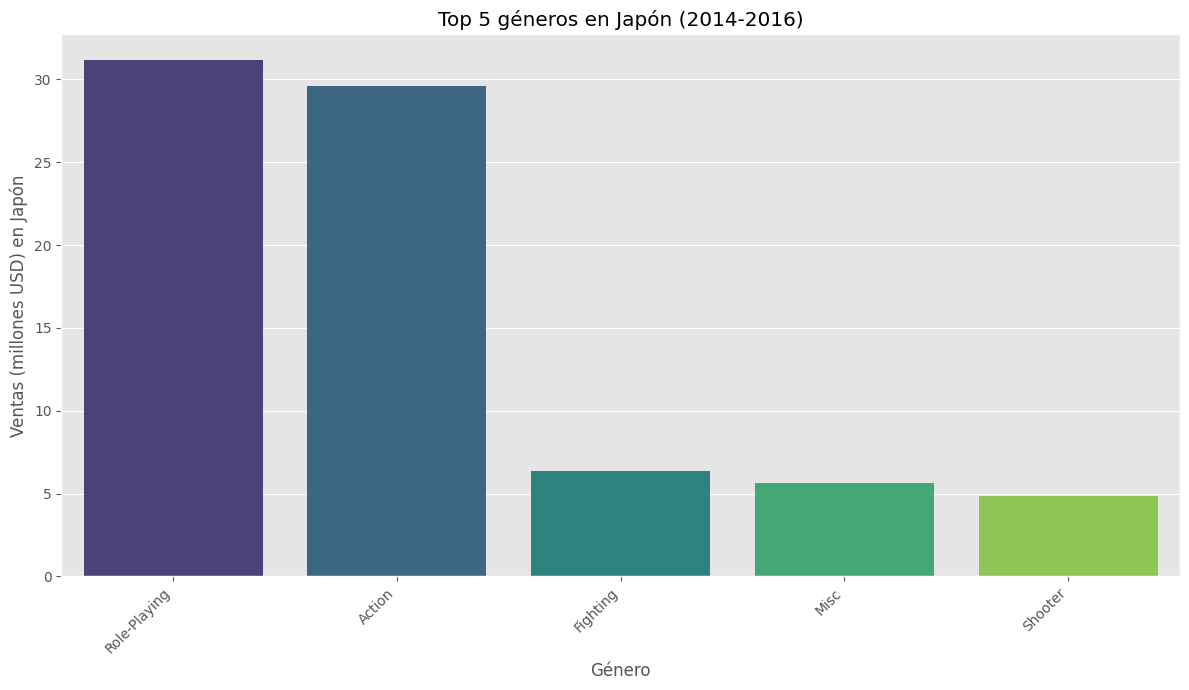

In [25]:
print("============ Top 5 géneros por región ============")
for region_col in regions:
    top_genres_region = df_current.groupby("genre")[region_col].sum().sort_values(ascending=False).head(5)

    print(f"\nTop 5 géneros en {region_names[region_col]} (2014-2016):")
    print(top_genres_region)

    plt.figure(figsize=(12, 7))
    sns.barplot(x=top_genres_region.index, y=top_genres_region.values, palette="viridis")
    plt.title(f"Top 5 géneros en {region_names[region_col]} (2014-2016)")
    plt.xlabel("Género")
    plt.ylabel(f"Ventas (millones USD) en {region_names[region_col]}")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

============ Impacto de las clasificaciones ESRB en las ventas por región ============
Valores de clasificación ESRB y sus conteos en el período 2014-2016:
NaN     749
T       271
M       265
E       219
E10+    185
Name: rating, dtype: int64

Ventas por Clasificación ESRB en Norteamérica (2014-2016):
rating
M            96.42
No Rating    64.72
E            50.74
T            38.95
E10+         33.23
Name: na_sales, dtype: float64


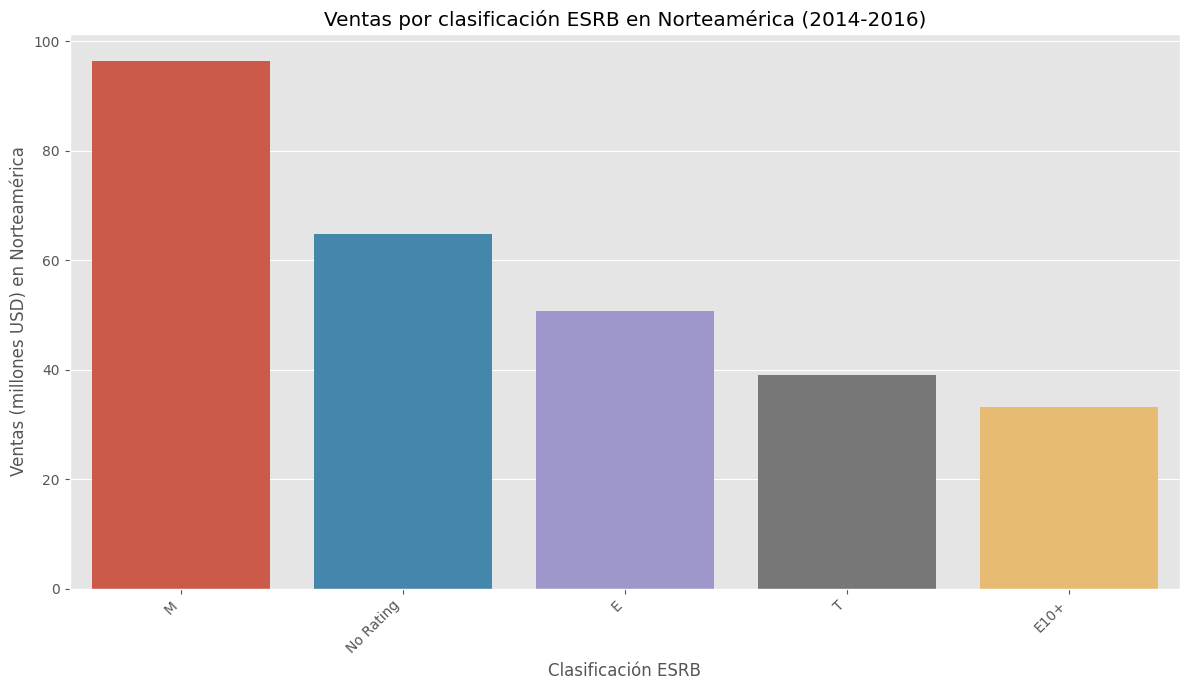


Ventas por Clasificación ESRB en Europa (2014-2016):
rating
M            93.44
No Rating    58.95
E            58.06
T            34.07
E10+         26.16
Name: eu_sales, dtype: float64


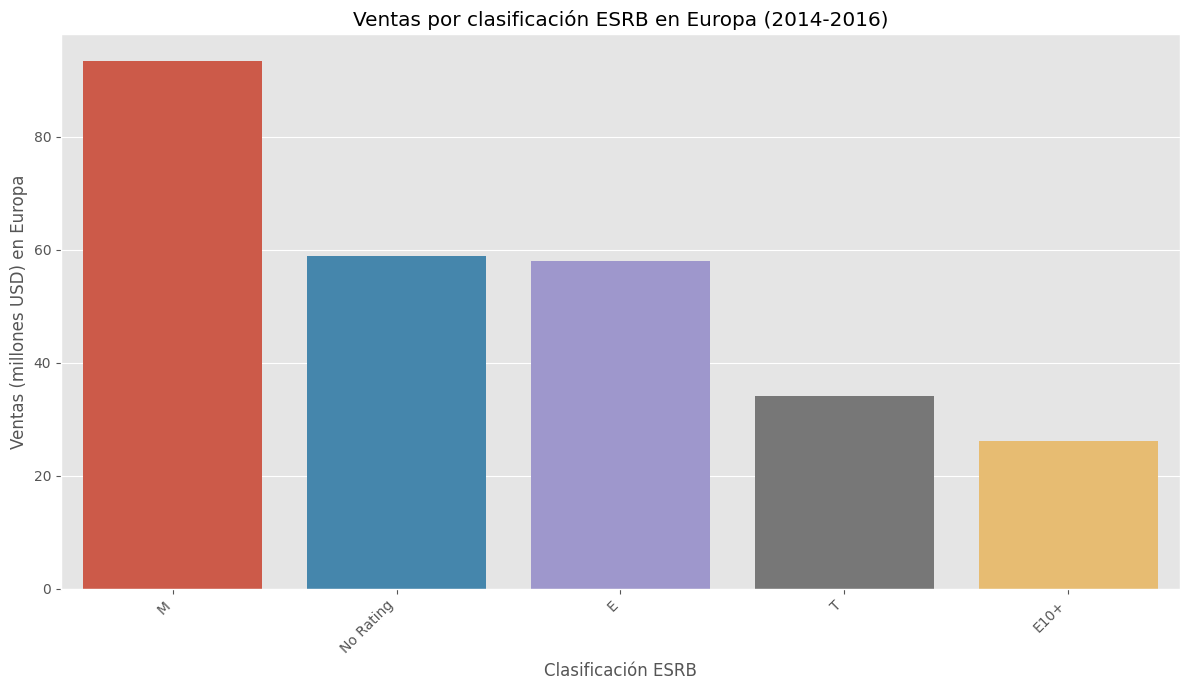


Ventas por Clasificación ESRB en Japón (2014-2016):
rating
No Rating    56.90
T            14.78
E             8.94
M             8.01
E10+          4.46
Name: jp_sales, dtype: float64


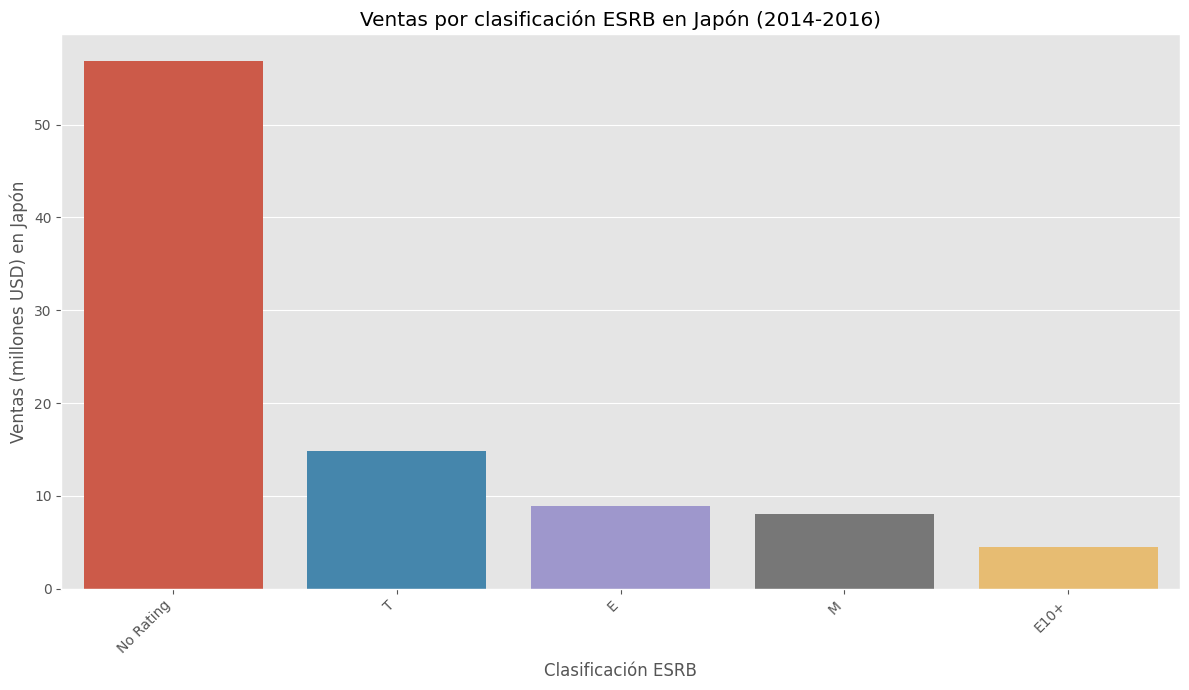

In [26]:
print("============ Impacto de las clasificaciones ESRB en las ventas por región ============")

print("Valores de clasificación ESRB y sus conteos en el período 2014-2016:")
print(df_current["rating"].value_counts(dropna=False)) # Incluyendo los juegos que no tienen rating
print("="*50)

df_current_with_rating = df_current.copy()
df_current_with_rating["rating"].fillna("No Rating", inplace=True)

for region_col in regions:
    sales_by_rating = df_current_with_rating.groupby("rating")[region_col].sum().sort_values(ascending=False)

    print(f"\nVentas por Clasificación ESRB en {region_names[region_col]} (2014-2016):")
    print(sales_by_rating)

    plt.figure(figsize=(12, 7))
    sns.barplot(x=sales_by_rating.index, y=sales_by_rating.values)
    plt.title(f"Ventas por clasificación ESRB en {region_names[region_col]} (2014-2016)")
    plt.xlabel("Clasificación ESRB")
    plt.ylabel(f"Ventas (millones USD) en {region_names[region_col]}")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

## Pruebas de hipótesis

In [27]:
print("============ Prueba de Hipótesis ============")
alpha = 0.05
print(f"Se establece el nivel de significancia (alfa): {alpha}")
print("="*50)

print("\n============ Hipótesis 1: Calificaciones promedio de usuarios (Xbox One vs. PC) ============")

user_scores_xone = df_current[(df_current["platform"] == "XOne") & (df_current["user_score"].notna())]["user_score"]
user_scores_pc = df_current[(df_current["platform"] == "PC") & (df_current["user_score"].notna())]["user_score"]

print(f"Número de muestras de user_score para Xbox One: {len(user_scores_xone)}")
print(f"Número de muestras de user_score para PC: {len(user_scores_pc)}")

print("\n============ Prueba de Levene para varianzas (H1) ============")
stat_levene_h1, p_value_levene_h1 = stats.levene(user_scores_xone, user_scores_pc)

print(f"resultado de Levene: {stat_levene_h1:.4f}")
print(f"Valor p de Levene: {p_value_levene_h1:.4f}")

are_variances_equal_h1 = p_value_levene_h1 >= alpha

if are_variances_equal_h1:
    print(f"El valor p de Levene ({p_value_levene_h1:.4f}) es mayor o igual que alfa ({alpha}).")
    print("No podemos rechazar la hipótesis nula de varianzas iguales. Asumiremos varianzas iguales para la prueba t.")
    equal_var_param_h1 = True
else:
    print(f"El valor p de Levene ({p_value_levene_h1:.4f}) es menor que alfa ({alpha}).")
    print("Rechazamos la hipótesis nula de varianzas iguales. Asumiremos varianzas desiguales para la prueba t.")
    equal_var_param_h1 = False

t_stat_h1, p_value_h1 = stats.ttest_ind(user_scores_xone, user_scores_pc, equal_var=equal_var_param_h1)

print(f"Resultado de t test: {t_stat_h1:.4f}")
print(f"Valor p: {p_value_h1:.4f}")

if p_value_h1 < alpha:
    print(f"El valor p ({p_value_h1:.4f}) es menor que alfa ({alpha}).")
    print("Por lo tanto, rechazamos la hipótesis nula.")
    print("Conclusión: Hay una diferencia estadísticamente significativa en las calificaciones promedio de los usuarios entre Xbox One y PC.")
else:
    print(f"El valor p ({p_value_h1:.4f}) es mayor o igual que alfa ({alpha}).")
    print("Por lo tanto, no podemos rechazar la hipótesis nula.")
    print("Conclusión: No hay evidencia estadística suficiente para afirmar que las calificaciones promedio de los usuarios entre Xbox One y PC son diferentes.")

============ Prueba de Hipótesis ============
Se establece el nivel de significancia (alfa): 0.05

============ Hipótesis 1: Calificaciones promedio de usuarios (Xbox One vs. PC) ============
Número de muestras de user_score para Xbox One: 165
Número de muestras de user_score para PC: 122

============ Prueba de Levene para varianzas (H1) ============
resultado de Levene: 6.0048
Valor p de Levene: 0.0149
El valor p de Levene (0.0149) es menor que alfa (0.05).
Rechazamos la hipótesis nula de varianzas iguales. Asumiremos varianzas desiguales para la prueba t.
Resultado de t test: 1.5778
Valor p: 0.1160
El valor p (0.1160) es mayor o igual que alfa (0.05).
Por lo tanto, no podemos rechazar la hipótesis nula.
Conclusión: No hay evidencia estadística suficiente para afirmar que las calificaciones promedio de los usuarios entre Xbox One y PC son diferentes.


In [28]:
print("\n============ Hipótesis 2: Calificaciones promedio de usuarios (Acción vs. Deportes) ============")

user_scores_action = df_current[(df_current["genre"] == "Action") & (df_current["user_score"].notna())]["user_score"]
user_scores_sports = df_current[(df_current["genre"] == "Sports") & (df_current["user_score"].notna())]["user_score"]

print(f"Número de muestras de user_score para Acción: {len(user_scores_action)}")
print(f"Número de muestras de user_score para Deportes: {len(user_scores_sports)}")

print("\n============ Prueba de Levene para varianzas (H2) ============")
stat_levene_h2, p_value_levene_h2 = stats.levene(user_scores_action, user_scores_sports)

print(f"Resultado de Levene: {stat_levene_h2:.4f}")
print(f"Valor p de Levene: {p_value_levene_h2:.4f}")

are_variances_equal_h2 = p_value_levene_h2 >= alpha

if are_variances_equal_h2:
    print(f"El valor p de Levene ({p_value_levene_h2:.4f}) es mayor o igual que alfa ({alpha}).")
    print("No podemos rechazar la hipótesis nula de varianzas iguales. Asumiremos varianzas iguales para la prueba t.")
    equal_var_param_h2 = True
else:
    print(f"El valor p de Levene ({p_value_levene_h2:.4f}) es menor que alfa ({alpha}).")
    print("Rechazamos la hipótesis nula de varianzas iguales. Asumiremos varianzas desiguales para la prueba t.")
    equal_var_param_h2 = False

t_stat_h2, p_value_h2 = stats.ttest_ind(user_scores_action, user_scores_sports, equal_var=equal_var_param_h2)

print(f"Estadístico t: {t_stat_h2:.4f}")
print(f"Valor p: {p_value_h2:.4f}")

if p_value_h2 < alpha:
    print(f"El valor p ({p_value_h2:.4f}) es menor que alfa ({alpha}).")
    print("Por lo tanto, rechazamos la hipótesis nula.")
    print("Conclusión: Hay una diferencia estadísticamente significativa en las calificaciones promedio de los usuarios entre los géneros Acción y Deportes.")
else:
    print(f"El valor p ({p_value_h2:.4f}) es mayor o igual que alfa ({alpha}).")
    print("Por lo tanto, no podemos rechazar la hipótesis nula.")
    print("Conclusión: No hay evidencia estadística suficiente para afirmar que las calificaciones promedio de los usuarios entre los géneros Acción y Deportes son diferentes.")


============ Hipótesis 2: Calificaciones promedio de usuarios (Acción vs. Deportes) ============
Número de muestras de user_score para Acción: 297
Número de muestras de user_score para Deportes: 127

============ Prueba de Levene para varianzas (H2) ============
Resultado de Levene: 21.6074
Valor p de Levene: 0.0000
El valor p de Levene (0.0000) es menor que alfa (0.05).
Rechazamos la hipótesis nula de varianzas iguales. Asumiremos varianzas desiguales para la prueba t.
Estadístico t: 8.3846
Valor p: 0.0000
El valor p (0.0000) es menor que alfa (0.05).
Por lo tanto, rechazamos la hipótesis nula.
Conclusión: Hay una diferencia estadísticamente significativa en las calificaciones promedio de los usuarios entre los géneros Acción y Deportes.


# Conclusion